In [1]:
# Cell 1 — Imports and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df = pd.read_csv('../data/featured_dataset.csv')
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nRisk Distribution:")
print(df['risk_level'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (1173364, 20)

Columns: ['timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'event_class', 'source', 'risk_level', 'accel_mag', 'gyro_mag', 'jerk', 'braking_intensity', 'turn_sharpness', 'harsh_accel_flag', 'harsh_brake_flag', 'harsh_turn_flag', 'tilt_angle', 'impact_score']

Risk Distribution:
risk_level
1    868274
2    300598
0      4492
Name: count, dtype: int64

Missing Values:
timestamp            176
accel_x              176
accel_y              176
accel_z              176
gyro_x               176
gyro_y               176
gyro_z               176
event_class            0
source                 0
risk_level             0
accel_mag            176
gyro_mag             176
jerk                   0
braking_intensity    176
turn_sharpness       176
harsh_accel_flag       0
harsh_brake_flag       0
harsh_turn_flag        0
tilt_angle           176
impact_score         176
dtype: int64

Basic Statistics:


,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,risk_level,accel_mag,gyro_mag,jerk,braking_intensity,turn_sharpness,harsh_accel_flag,harsh_brake_flag,harsh_turn_flag,tilt_angle,impact_score
count,1.173188e+06,1.173188e+06,1.173188e+06,1.173188e+06,1.173188e+06,1.173188e+06,1.173364e+06,1.173188e+06,1.173188e+06,1.173364e+06,1.173188e+06,1.173188e+06,1.173364e+06,1.173364e+06,1.173364e+06,1.173188e+06,1.173188e+06
mean,1.735864e-01,4.987311e-02,9.016623e+00,-1.339855e-01,-1.902425e+00,5.520167e-01,1.252356e+00,9.451328e+00,1.083759e+01,1.099272e-01,4.182981e-02,6.030333e+00,8.012007e-03,2.769814e-04,6.480197e-01,3.306912e+00,7.064791e+00
std,2.316161e+00,4.740052e-01,3.304110e+00,9.920922e+00,9.836078e+00,1.113834e+01,4.430908e-01,2.917350e+00,1.434309e+01,5.786854e-01,3.961397e-01,9.380963e+00,8.915055e-02,1.664046e-02,4.775881e-01,1.773233e+01,4.543457e+00
min,-3.874265e+01,-2.477564e+01,-5.838731e+01,-1.096150e+02,-1.086320e+02,-9.169600e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e+01,0.000000e+00
25%,-3.968552e-01,2.200000e-02,9.580000e+00,-2.161000e+00,-2.178000e+00,-8.140000e-01,1.000000e+00,9.630679e+00,1.218253e+00,0.000000e+00,0.000000e+00,2.710000e-01,0.000000e+00,0.000000e+00,0.000000e+00,-2.614720e+00,4.284843e+00
50%,0.000000e+00,4.800000e-02,9.867000e+00,-6.800000e-02,5.340000e-01,2.630000e-01,1.000000e+00,9.964667e+00,4.861084e+00,1.999618e-03,0.000000e+00,1.085000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,5.529215e+00
75%,8.640000e-01,9.400000e-02,1.034500e+01,1.899000e+00,1.085000e+00,1.144000e+00,2.000000e+00,1.069622e+01,1.663103e+01,4.799810e-02,0.000000e+00,8.680000e+00,0.000000e+00,0.000000e+00,1.000000e+00,8.364150e+00,9.244982e+00
max,3.973736e+01,4.020275e+01,2.012419e+01,1.096070e+02,6.956500e+01,1.090300e+02,2.000000e+00,6.991963e+01,1.805730e+02,6.801772e+01,2.477564e+01,1.090300e+02,1.000000e+00,1.000000e+00,1.000000e+00,9.000000e+01,5.649748e+01


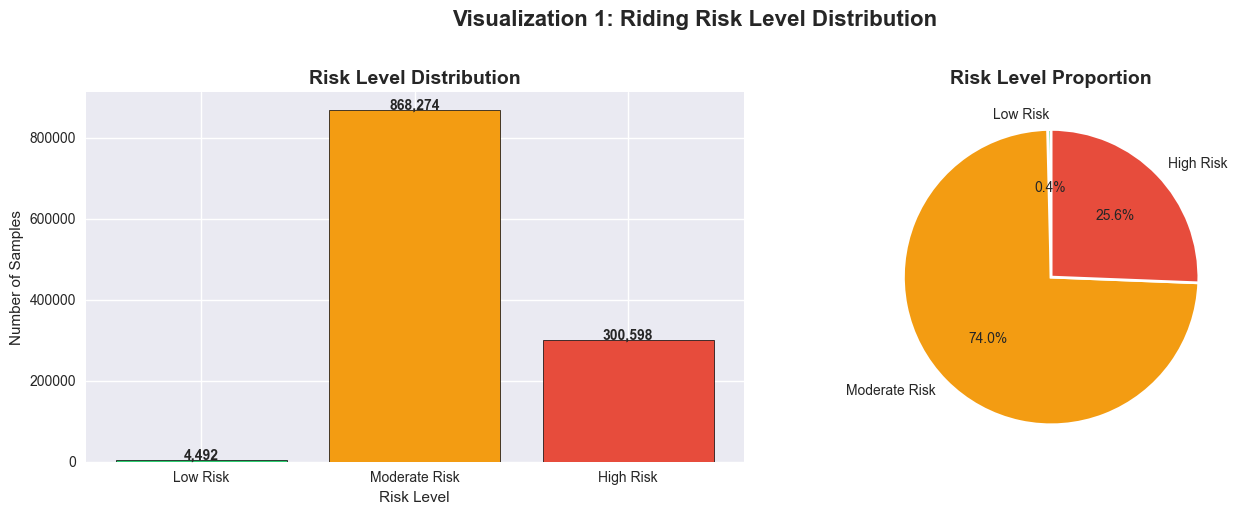

✅ Visualization 1 saved


In [2]:
# Cell 2 — VISUALIZATION 1: Risk Level Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
risk_counts = df['risk_level'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
labels = ['Low Risk', 'Moderate Risk', 'High Risk']

axes[0].bar(labels, risk_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Risk Level')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    risk_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Risk Level Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Visualization 1: Riding Risk Level Distribution', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/viz1_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 1 saved")

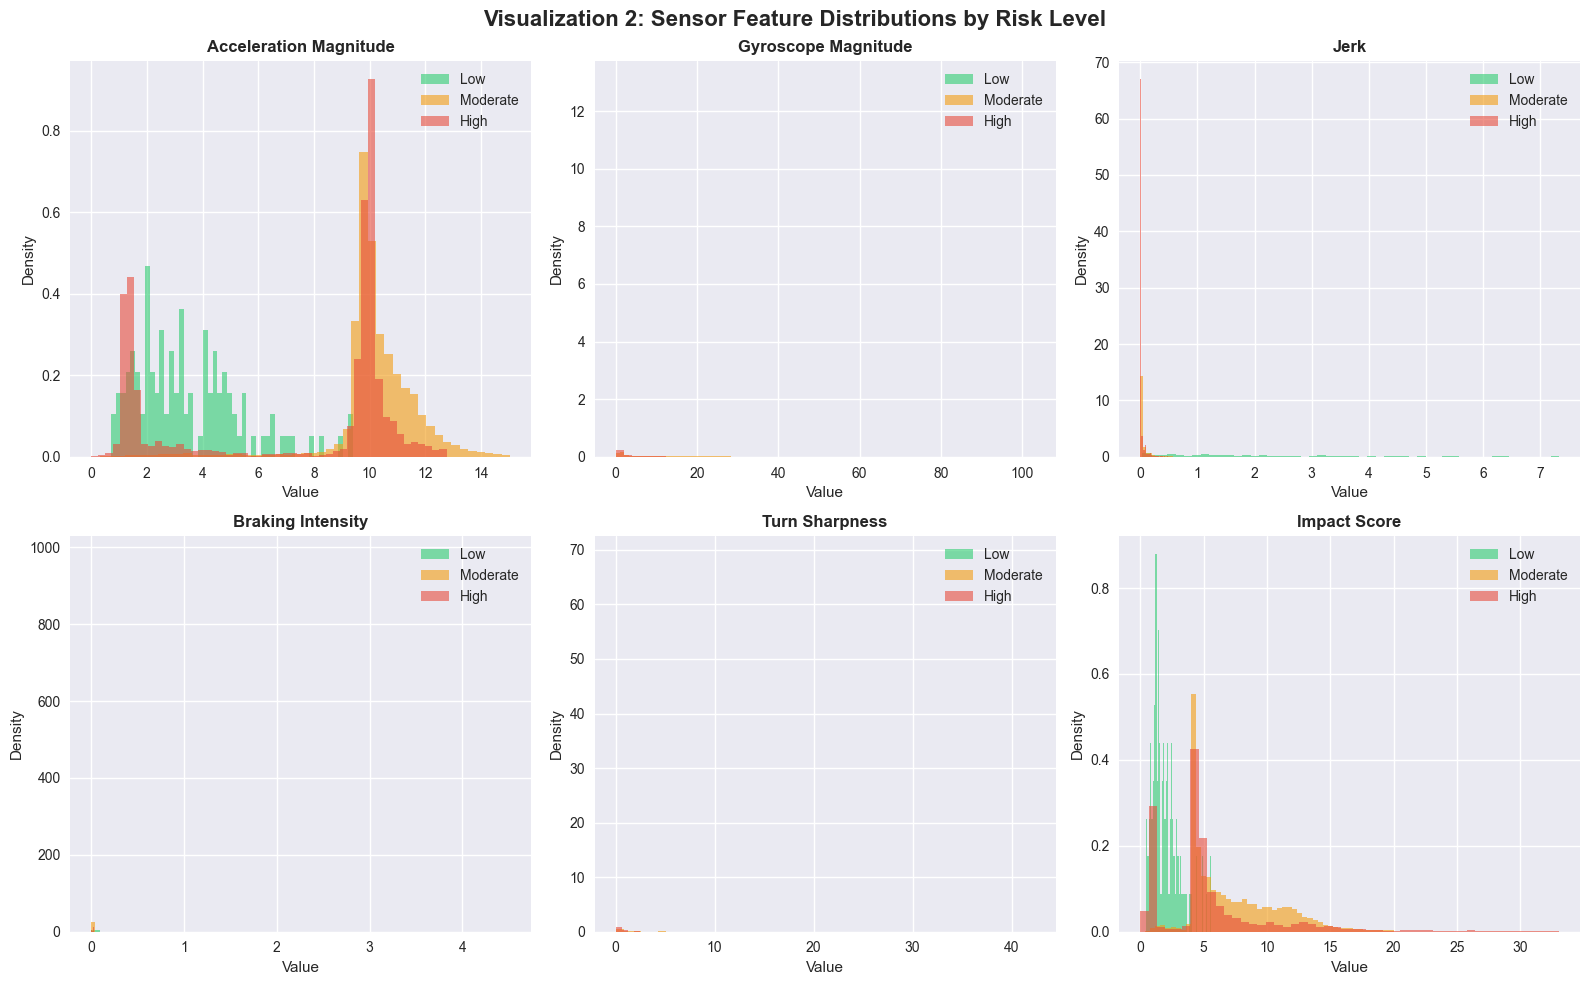

✅ Visualization 2 saved


In [3]:
# Cell 3 — VISUALIZATION 2: Sensor Data Distribution by Risk Level
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['accel_mag', 'gyro_mag', 'jerk', 
            'braking_intensity', 'turn_sharpness', 'impact_score']
titles   = ['Acceleration Magnitude', 'Gyroscope Magnitude', 'Jerk',
            'Braking Intensity', 'Turn Sharpness', 'Impact Score']
colors   = ['#2ecc71', '#f39c12', '#e74c3c']
labels   = ['Low', 'Moderate', 'High']

sample = df.sample(n=min(30000, len(df)), random_state=42)

for idx, (feat, title) in enumerate(zip(features, titles)):
    ax = axes[idx // 3][idx % 3]
    for risk, color, label in zip([0, 1, 2], colors, labels):
        data = sample[sample['risk_level'] == risk][feat].dropna()
        data = data[data < data.quantile(0.99)]
        ax.hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Visualization 2: Sensor Feature Distributions by Risk Level',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/viz2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 2 saved")

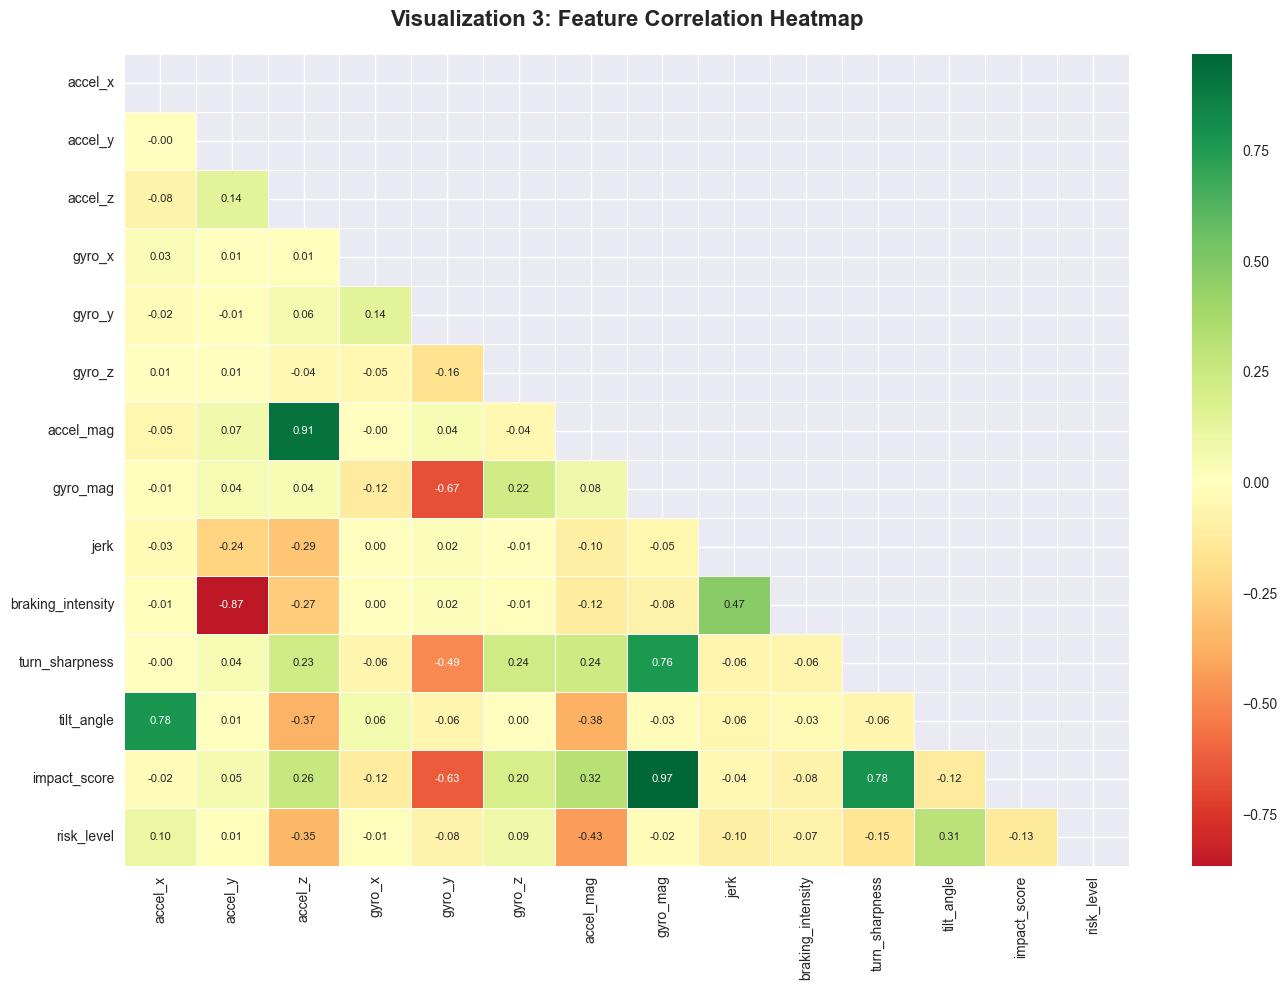

✅ Visualization 3 saved


In [4]:
# Cell 4 — VISUALIZATION 3: Correlation Heatmap
feature_cols = [
    'accel_x', 'accel_y', 'accel_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'accel_mag', 'gyro_mag', 'jerk',
    'braking_intensity', 'turn_sharpness',
    'tilt_angle', 'impact_score', 'risk_level'
]

sample_corr = df[feature_cols].sample(n=min(10000, len(df)), random_state=42)
corr_matrix = sample_corr.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Visualization 3: Feature Correlation Heatmap',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../models/viz3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 3 saved")

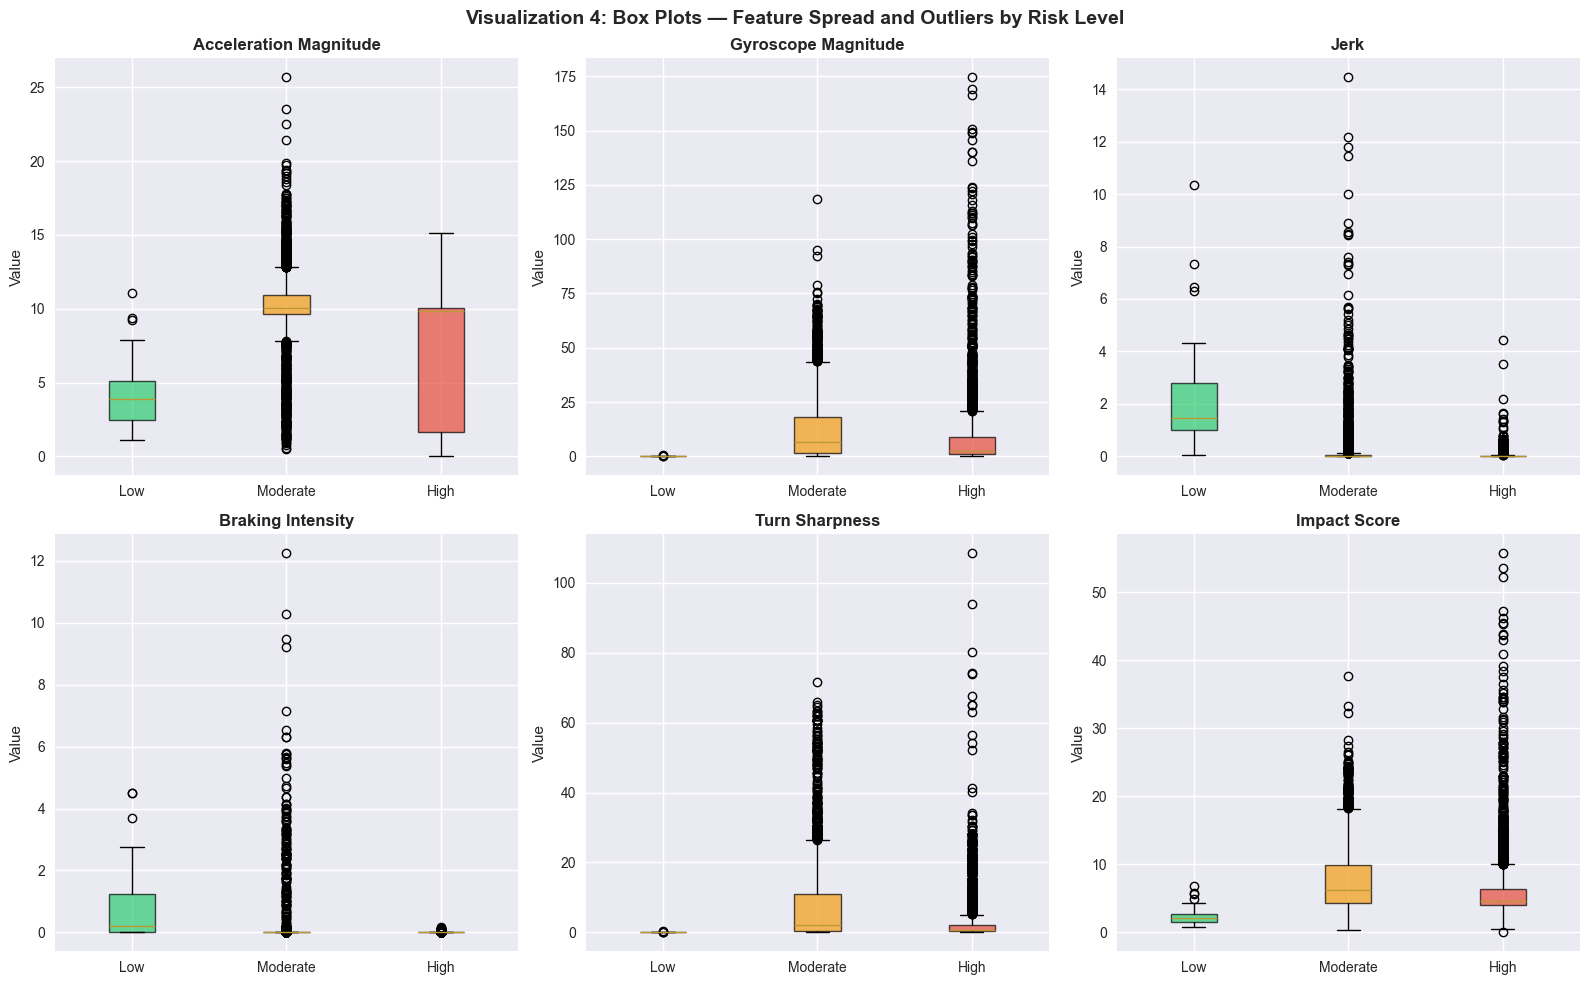

✅ Visualization 4 saved


In [5]:
# Cell 5 — VISUALIZATION 4: Box Plots — Outlier Detection
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['accel_mag', 'gyro_mag', 'jerk',
            'braking_intensity', 'turn_sharpness', 'impact_score']
titles   = ['Acceleration Magnitude', 'Gyroscope Magnitude', 'Jerk',
            'Braking Intensity', 'Turn Sharpness', 'Impact Score']

sample = df.sample(n=min(10000, len(df)), random_state=42)

for idx, (feat, title) in enumerate(zip(features, titles)):
    ax = axes[idx // 3][idx % 3]
    data = [
        sample[sample['risk_level'] == 0][feat].dropna().values,
        sample[sample['risk_level'] == 1][feat].dropna().values,
        sample[sample['risk_level'] == 2][feat].dropna().values
    ]
    bp = ax.boxplot(data, patch_artist=True, labels=['Low', 'Moderate', 'High'])
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Visualization 4: Box Plots — Feature Spread and Outliers by Risk Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/viz4_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 4 saved")

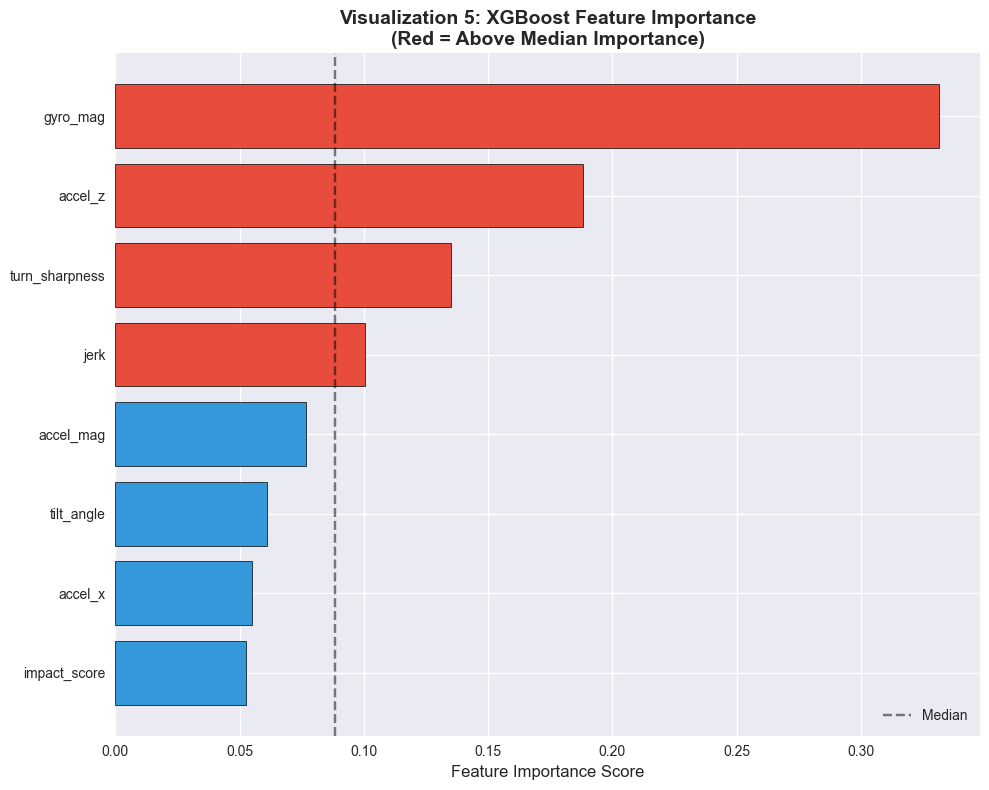

✅ Visualization 5 saved


In [6]:
# Cell 6 — VISUALIZATION 5: Feature Importance
import joblib

xgb_model = joblib.load('../models/xgb_model.pkl')
selected_features = joblib.load('../models/selected_features.pkl')

importances = pd.Series(
    xgb_model.feature_importances_,
    index=selected_features
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > importances.median() else '#3498db' 
          for x in importances.values]
bars = plt.barh(importances.index, importances.values, color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Visualization 5: XGBoost Feature Importance\n(Red = Above Median Importance)',
          fontsize=14, fontweight='bold')
plt.axvline(x=importances.median(), color='black', linestyle='--', alpha=0.5, label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('../models/viz5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 5 saved")

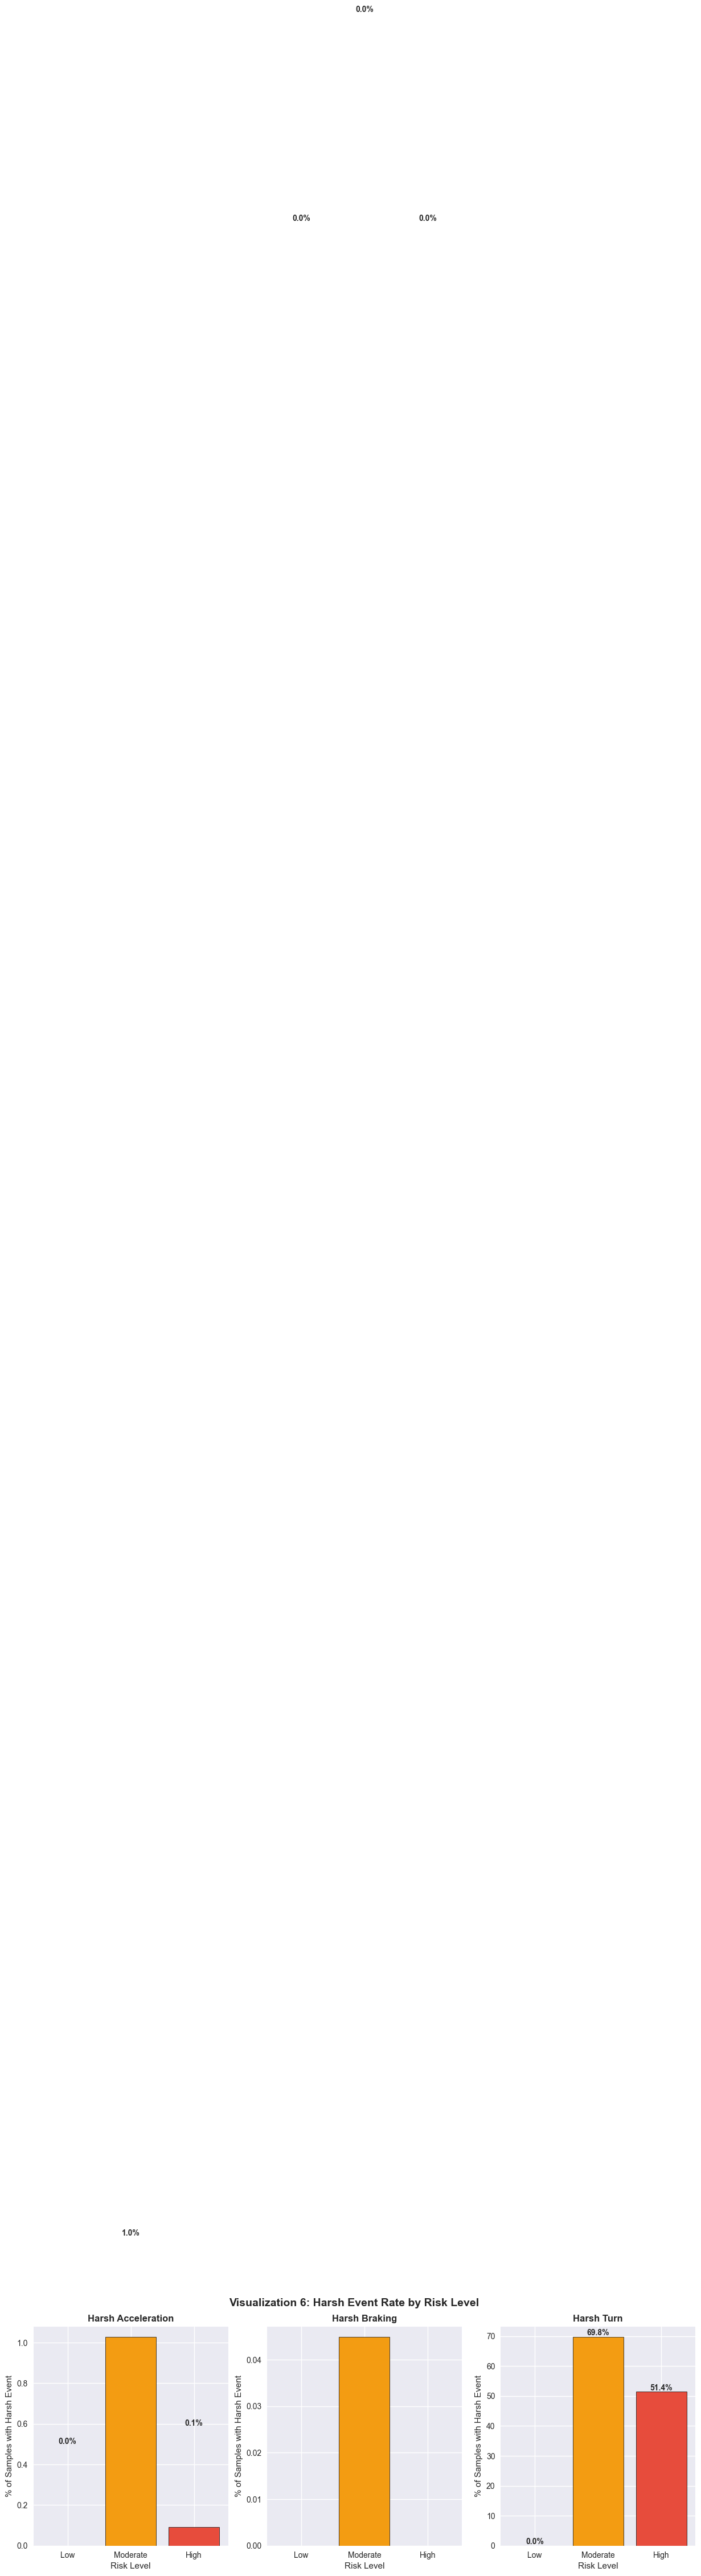

✅ Visualization 6 saved


In [7]:
# Cell 7 — VISUALIZATION 6: Harsh Events Count by Risk Level
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
harsh_features = ['harsh_accel_flag', 'harsh_brake_flag', 'harsh_turn_flag']
harsh_titles   = ['Harsh Acceleration', 'Harsh Braking', 'Harsh Turn']

sample = df.sample(n=min(30000, len(df)), random_state=42)

for idx, (feat, title) in enumerate(zip(harsh_features, harsh_titles)):
    ax = axes[idx]
    data = sample.groupby('risk_level')[feat].mean() * 100
    bars = ax.bar(
        ['Low', 'Moderate', 'High'],
        data.values,
        color=['#2ecc71', '#f39c12', '#e74c3c'],
        edgecolor='black', linewidth=0.5
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('% of Samples with Harsh Event')
    ax.set_xlabel('Risk Level')
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Visualization 6: Harsh Event Rate by Risk Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/viz6_harsh_events.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization 6 saved")

In [8]:
# Cell 8 — Summary
print("=" * 50)
print("EDA COMPLETE")
print("=" * 50)
print("\n6 Visualizations saved to models/:")
print("  viz1_risk_distribution.png")
print("  viz2_feature_distributions.png")
print("  viz3_correlation_heatmap.png")
print("  viz4_boxplots.png")
print("  viz5_feature_importance.png")
print("  viz6_harsh_events.png")

print("\nKey Findings:")
print(f"  Total samples      : {len(df):,}")
print(f"  Features used      : 16")
print(f"  Risk levels        : 3 (Low, Moderate, High)")
print(f"  Missing values     : {df.isnull().sum().sum()}")

sample = df.sample(n=min(10000, len(df)), random_state=42)
print(f"\n  Avg accel_mag (Low)  : {sample[sample['risk_level']==0]['accel_mag'].mean():.2f}")
print(f"  Avg accel_mag (High) : {sample[sample['risk_level']==2]['accel_mag'].mean():.2f}")
print(f"\n  Avg impact (Low)     : {sample[sample['risk_level']==0]['impact_score'].mean():.2f}")
print(f"  Avg impact (High)    : {sample[sample['risk_level']==2]['impact_score'].mean():.2f}")

EDA COMPLETE

6 Visualizations saved to models/:
  viz1_risk_distribution.png
  viz2_feature_distributions.png
  viz3_correlation_heatmap.png
  viz4_boxplots.png
  viz5_feature_importance.png
  viz6_harsh_events.png

Key Findings:
  Total samples      : 1,173,364
  Features used      : 16
  Risk levels        : 3 (Low, Moderate, High)
  Missing values     : 2288

  Avg accel_mag (Low)  : 4.28
  Avg accel_mag (High) : 7.28

  Avg impact (Low)     : 2.40
  Avg impact (High)    : 5.99
